# Exp7.2.6.4 — Frozen-L2 output-interface decomposition

Analysis-only notebook. It reads finalized aggregate artifacts and compares Parts A–D across seeds. No training or inference is run here.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'notebooks').exists():
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_6_4_output_interface_decomposition' / 'output_interface_decomposition_v1'
manifest = json.loads((ART / 'manifest.json').read_text())
manifest


{'architecture': '234x234',
 'cache_tasks': 3,
 'ce_gains': [1.0, 2.0, 5.0, 10.0],
 'experiment_id': 'experiment_7_2_6_4_output_interface_decomposition',
 'flush_steps': [0, 1, 2, 4, 8, 16, 32, 64, 128],
 'frozen_l1_l2_throughout': True,
 'gradient_tasks': 3,
 'no_e2e_retraining': True,
 'notebook_contract': 'analysis-only; reads finalized aggregate CSV/JSON artifacts only',
 'part_a_question': 'Is beta=1 count failure a finite output-bandwidth/residual-discharge problem?',
 'part_a_tasks': 3,
 'part_b_question': 'How much do signed negative evidence and evidence normalization matter for a fixed good W?',
 'part_b_tasks': 3,
 'part_c_question': 'How do Raw-WCCE, softmax-vote WCCE, and TSCE shape W on the same frozen L2?',
 'part_c_training_tasks': 9,
 'part_d_question': 'Is W_lif degradation CE-scale conditioning or LIF/surrogate-gradient geometry?',
 'part_d_training_tasks': 27,
 'protocol_version': 'output_interface_decomposition_v1',
 'regularization': 'task_only',
 'seeds': [11, 23

## Part A — residual discharge / output bandwidth

,condition,balanced_accuracy_mean,balanced_accuracy_std
0,analog,0.545353,0.013146
1,if_beta1_charge,0.545353,0.013146
2,if_beta1_count,0.321903,0.035217
3,lif_beta05_count,0.527769,0.019265


,beta,balanced_accuracy_mean,balanced_accuracy_std,mean_extra_spikes_per_sample_mean
0,1.0,0.537086,0.022126,343.694064


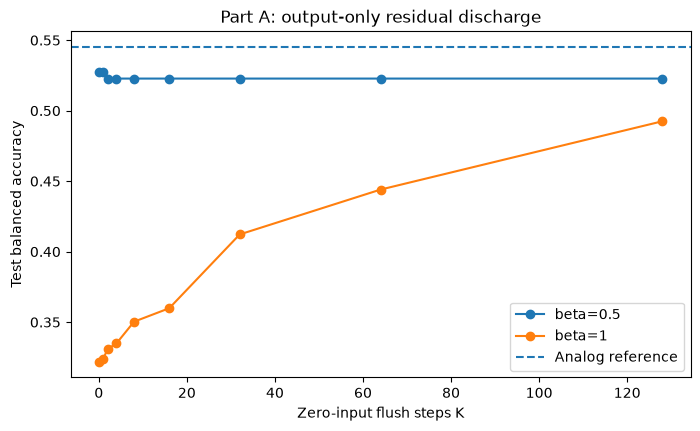

In [2]:
a_ref = pd.read_csv(ART / 'part_a_reference_summary.csv')
a_flush = pd.read_csv(ART / 'part_a_flush_summary.csv')
a_inf = pd.read_csv(ART / 'part_a_infinite_flush_summary.csv')
display(a_ref[['condition', 'balanced_accuracy_mean', 'balanced_accuracy_std']])
display(a_inf[['beta', 'balanced_accuracy_mean', 'balanced_accuracy_std', 'mean_extra_spikes_per_sample_mean']])
fig, ax = plt.subplots(figsize=(8, 4.5))
for beta, group in a_flush.groupby('beta'):
    group = group.sort_values('flush_steps')
    ax.plot(group['flush_steps'], group['balanced_accuracy_mean'], marker='o', label=f'beta={beta:g}')
analog = a_ref.loc[a_ref.condition == 'analog', 'balanced_accuracy_mean'].iloc[0]
ax.axhline(analog, linestyle='--', label='Analog reference')
ax.set_xlabel('Zero-input flush steps K')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Part A: output-only residual discharge')
ax.legend()
plt.show()


## Part B — evidence semantics

,condition,temperature,balanced_accuracy_mean,balanced_accuracy_std
0,lif_beta05,NaN,0.527769,0.019265
1,positive_only,NaN,0.503867,0.011617
2,raw_signed,NaN,0.545353,0.013146
3,softmax_vote,0.25,0.444755,0.014969
4,softmax_vote,0.50,0.452120,0.001625
5,softmax_vote,1.00,0.455051,0.009040
6,softmax_vote,2.00,0.483593,0.005532


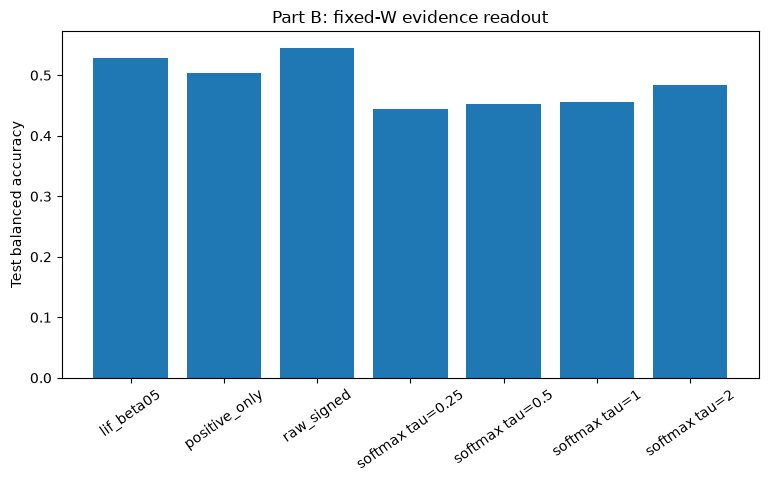

In [3]:
b = pd.read_csv(ART / 'part_b_evidence_semantics_summary.csv')
b_test = b[b.split == 'test'].copy()
display(b_test[['condition', 'temperature', 'balanced_accuracy_mean', 'balanced_accuracy_std']])
labels = []
values = []
for _, row in b_test.iterrows():
    label = row['condition'] if pd.isna(row['temperature']) else f"softmax tau={row['temperature']:g}"
    labels.append(label)
    values.append(row['balanced_accuracy_mean'])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(labels, values)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Part B: fixed-W evidence readout')
ax.tick_params(axis='x', rotation=35)
plt.show()


## Part C — objective × evaluation-readout cross-check

evaluation_readout,analog,lif_beta05,softmax_vote
training_objective,,,
raw_wcce,0.549818,0.499776,0.493580
softmax_vote_wcce,0.518719,0.483901,0.488769
tsce,0.517756,0.520798,0.500748


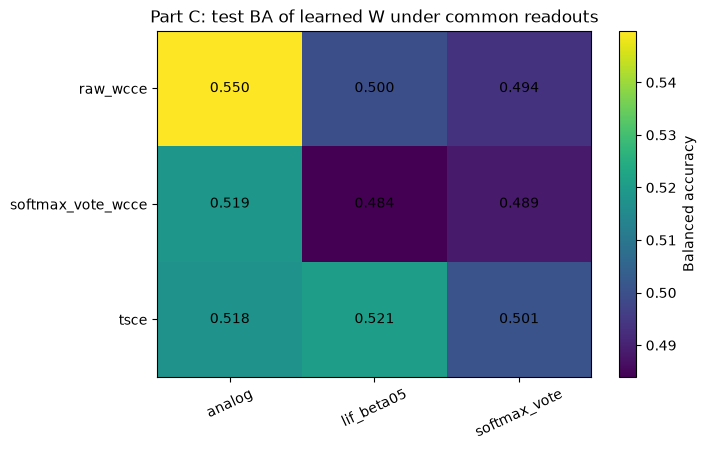

In [4]:
c = pd.read_csv(ART / 'part_c_objective_training_summary.csv')
c_test = c[c.split == 'test'].copy()
c_matrix = c_test.pivot(index='training_objective', columns='evaluation_readout', values='balanced_accuracy_mean')
display(c_matrix)
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(c_matrix.values, aspect='auto')
ax.set_xticks(range(len(c_matrix.columns)), c_matrix.columns, rotation=25)
ax.set_yticks(range(len(c_matrix.index)), c_matrix.index)
for i in range(c_matrix.shape[0]):
    for j in range(c_matrix.shape[1]):
        ax.text(j, i, f'{c_matrix.iloc[i, j]:.3f}', ha='center', va='center')
ax.set_title('Part C: test BA of learned W under common readouts')
fig.colorbar(im, ax=ax, label='Balanced accuracy')
plt.show()


## Part D — CE gain and gradient geometry

,head_type,ce_gain,balanced_accuracy_mean,balanced_accuracy_std
0,lif,1.0,0.486911,0.024598
9,lif,2.0,0.497581,0.018195
27,lif,5.0,0.502891,0.008145
36,lif,10.0,0.493463,0.005397
45,linear,1.0,0.549818,0.021133
54,linear,2.0,0.537706,0.008429
63,linear,5.0,0.540695,0.008473
72,linear,10.0,0.519032,0.008467


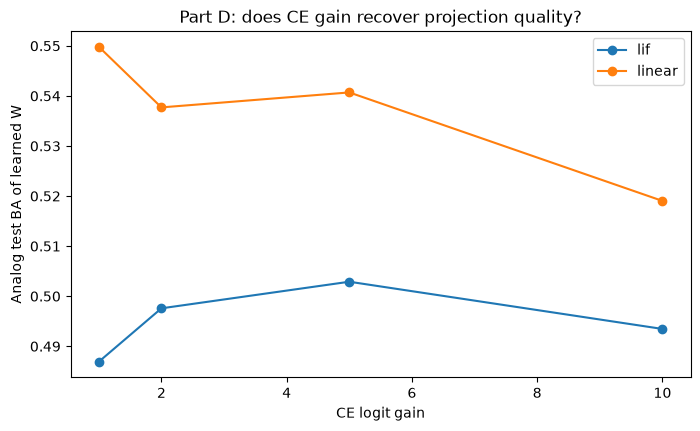

In [5]:
d = pd.read_csv(ART / 'part_d_gain_sweep_summary.csv')
d_primary = d[(d.split == 'test') & (d.evaluation_readout == 'analog') & (d.lr_scale == 1.0)].copy()
display(d_primary[['head_type', 'ce_gain', 'balanced_accuracy_mean', 'balanced_accuracy_std']])
fig, ax = plt.subplots(figsize=(8, 4.5))
for head, group in d_primary.groupby('head_type'):
    group = group.sort_values('ce_gain')
    ax.plot(group['ce_gain'], group['balanced_accuracy_mean'], marker='o', label=head)
ax.set_xlabel('CE logit gain')
ax.set_ylabel('Analog test BA of learned W')
ax.set_title('Part D: does CE gain recover projection quality?')
ax.legend()
plt.show()


,ce_gain,global_cosine_mean,norm_ratio_lif_over_linear_mean
0,1.0,0.567195,0.102469
1,2.0,0.692817,0.114904
2,5.0,0.890328,0.134509
3,10.0,0.942612,0.134545


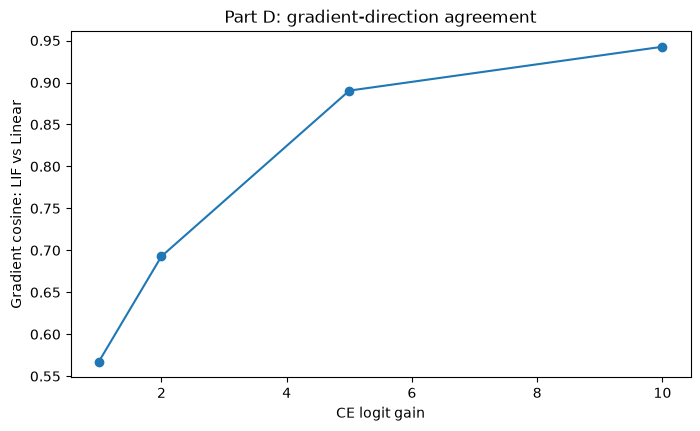

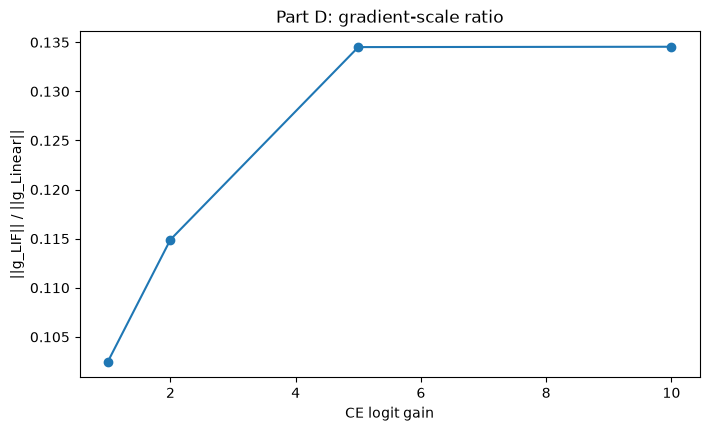

In [6]:
g = pd.read_csv(ART / 'part_d_gradient_geometry_summary.csv').sort_values('ce_gain')
display(g[['ce_gain', 'global_cosine_mean', 'norm_ratio_lif_over_linear_mean']])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(g['ce_gain'], g['global_cosine_mean'], marker='o')
ax.set_xlabel('CE logit gain')
ax.set_ylabel('Gradient cosine: LIF vs Linear')
ax.set_title('Part D: gradient-direction agreement')
plt.show()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(g['ce_gain'], g['norm_ratio_lif_over_linear_mean'], marker='o')
ax.set_xlabel('CE logit gain')
ax.set_ylabel('||g_LIF|| / ||g_Linear||')
ax.set_title('Part D: gradient-scale ratio')
plt.show()


## Interpretation checklist

- Part A: compare finite flush, theoretical infinite IF flush, and charge-preserving reference.
- Part B: `raw_signed` vs `positive_only` isolates negative-evidence removal; softmax vote additionally removes raw evidence mass.
- Part C: C0 vs C1 tests raw signed/amplitude accumulation vs normalized positive voting; C1 vs C2 tests temporal compensation vs mandatory per-timestep correctness pressure.
- Part D: the primary diagnostic is Analog BA of `W_lif` as CE gain changes; gradient cosine distinguishes scale from direction changes.